<a href="https://colab.research.google.com/github/GabrielaRguezCampos/Heat_equation_time_dependent_solution/blob/main/HEAT_EQUATION_ANIMATION_EXPORTABLE_GIF_VERSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEAT EQUATION ANIMATION GENERATOR

Boundary Conditions:
  Top:    100.0°C
  Bottom: 100.0°C
  Left:   100.0°C
  Right:  100.0°C
  Initial interior: 0.0°C

Settings: k=0.0, source=0

Running simulation...
✓ Generated 61 frames
  Final center temp: 100.0°C
  Final interior avg: 100.0°C

Creating animation...

Displaying animation...



----------------------------------------
To save as GIF, uncomment and run:
----------------------------------------

# Save animation as GIF
anim.save('heat_evolution.gif', writer='pillow', fps=fps)
print("✓ Saved as 'heat_evolution.gif'")

# Or save as MP4 (requires ffmpeg)
# anim.save('heat_evolution.mp4', writer='ffmpeg', fps=fps)


BONUS: 3D SURFACE VISUALIZATION



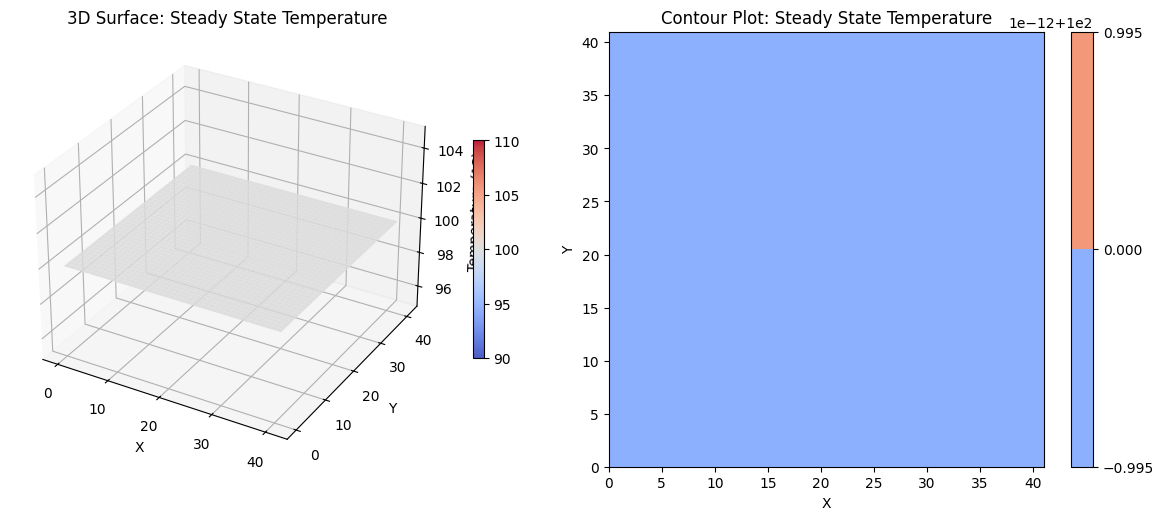


✓ All visualizations complete!

This animation shows the 'journey' from initial state to steady state.
Your Jacobi method finds this same steady state directly!


In [ ]:
# =============================================================================
# HEAT EQUATION ANIMATION - EXPORTABLE GIF VERSION
# =============================================================================
# This creates a GIF animation showing temperature evolution to steady state.
# Perfect for embedding in presentations or reports!
#
# Run in Google Colab. The animation will display AND save as a GIF file.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

# =============================================================================
# CONFIGURATION - MODIFY FOR YOUR SPECIFIC PROBLEM
# =============================================================================

# Grid size
n = 40  # n×n interior points

# BOUNDARY CONDITIONS - MODIFY THESE!
# Option 1: Heat on 2 sides (top/bottom hot, left/right cold)
#T_top = 100.0
#T_bottom = 100.0
#T_left = 0.0
#T_right = 0.0

# Option 2: All sides at 100°C (uncomment to use)
T_top = T_bottom = T_left = T_right = 100.0
T_initial = 0.0  # Start cold inside, watch it warm up to 100°C

# Option 3: Custom (e.g., one side hot)
# T_top = 100.0
# T_bottom = 0.0
# T_left = 0.0
# T_right = 0.0

# Initial interior temperature
#T_initial = 25.0  # Starting temperature inside

# Reaction term
k = 0.0  # k>0: cooling to environment, k<0: internal heating, k=0: pure diffusion

# Heat source at center
source_strength = 0  # Try 200-500 to add a point heat source

# Animation settings
total_time = 2.0
num_frames = 60
fps = 15

print("="*60)
print("HEAT EQUATION ANIMATION GENERATOR")
print("="*60)
print(f"\nBoundary Conditions:")
print(f"  Top:    {T_top}°C")
print(f"  Bottom: {T_bottom}°C")
print(f"  Left:   {T_left}°C")
print(f"  Right:  {T_right}°C")
print(f"  Initial interior: {T_initial}°C")
print(f"\nSettings: k={k}, source={source_strength}")

# =============================================================================
# SIMULATION SETUP
# =============================================================================

N = n + 2  # Total grid size including boundaries
dx = 1.0 / (n + 1)
dt = 0.2 * dx**2  # Stable time step
steps_per_frame = max(1, int((total_time / num_frames) / dt))

# Initialize grid
def init_grid():
    u = np.ones((N, N)) * T_initial
    u[0, :] = T_top
    u[-1, :] = T_bottom
    u[:, 0] = T_left
    u[:, -1] = T_right
    return u

# Source term
f = np.zeros((N, N))
if source_strength > 0:
    center = N // 2
    f[center-1:center+2, center-1:center+2] = source_strength

# Time step function
def step(u):
    laplacian = (u[2:,1:-1] + u[:-2,1:-1] + u[1:-1,2:] + u[1:-1,:-2] - 4*u[1:-1,1:-1]) / dx**2
    u_new = u.copy()
    u_new[1:-1,1:-1] = u[1:-1,1:-1] + dt * (laplacian - k*u[1:-1,1:-1] + f[1:-1,1:-1])
    u_new[0,:] = T_top
    u_new[-1,:] = T_bottom
    u_new[:,0] = T_left
    u_new[:,-1] = T_right
    return u_new

# =============================================================================
# RUN SIMULATION
# =============================================================================

print("\nRunning simulation...")
u = init_grid()
frames = [u.copy()]
times = [0.0]
t = 0.0

for i in range(num_frames):
    for _ in range(steps_per_frame):
        u = step(u)
        t += dt
    frames.append(u.copy())
    times.append(t)

print(f"✓ Generated {len(frames)} frames")
print(f"  Final center temp: {u[N//2, N//2]:.1f}°C")
print(f"  Final interior avg: {u[1:-1,1:-1].mean():.1f}°C")

# =============================================================================
# CREATE ANIMATION
# =============================================================================

print("\nCreating animation...")

# Color scale
vmin = min(T_left, T_right, T_top, T_bottom, T_initial, 0)
vmax = max(T_left, T_right, T_top, T_bottom, T_initial) + 20

# Set up figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Heatmap
im = ax1.imshow(frames[0], cmap='coolwarm', vmin=vmin, vmax=vmax, animated=True)
ax1.set_title('Temperature Distribution', fontsize=14)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
cbar = plt.colorbar(im, ax=ax1, label='Temperature (°C)')

# Boundary labels
ax1.text(N/2, -2, f'Top: {T_top}°C', ha='center', fontsize=9, color='darkred')
ax1.text(N/2, N+1, f'Bottom: {T_bottom}°C', ha='center', fontsize=9, color='darkred')
ax1.text(-3, N/2, f'Left:\n{T_left}°C', ha='center', va='center', fontsize=9, color='darkblue')
ax1.text(N+2, N/2, f'Right:\n{T_right}°C', ha='center', va='center', fontsize=9, color='darkblue')

# Title with time
time_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, fontsize=12,
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right: Temperature history
center_temps = [frame[N//2, N//2] for frame in frames]
line, = ax2.plot([], [], 'b-', linewidth=2)
point, = ax2.plot([], [], 'ro', markersize=10)
ax2.set_xlim(0, times[-1])
ax2.set_ylim(vmin, vmax)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Center Temperature (°C)', fontsize=12)
ax2.set_title('Temperature at Center vs Time', fontsize=14)
ax2.grid(True, alpha=0.3)

# Steady state reference line
ax2.axhline(y=center_temps[-1], color='green', linestyle='--', alpha=0.7,
            label=f'Steady state: {center_temps[-1]:.1f}°C')
ax2.legend(loc='best')

plt.tight_layout()

def animate(i):
    """Update function for animation."""
    im.set_array(frames[i])
    time_text.set_text(f't = {times[i]:.3f}\nCenter: {frames[i][N//2,N//2]:.1f}°C')

    line.set_data(times[:i+1], center_temps[:i+1])
    point.set_data([times[i]], [center_temps[i]])

    return [im, time_text, line, point]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(frames),
                                interval=1000//fps, blit=True)

# =============================================================================
# DISPLAY AND SAVE
# =============================================================================

# Display in notebook
plt.close()  # Prevent static display
print("\nDisplaying animation...")
display(HTML(anim.to_jshtml()))

# Save as GIF (uncomment to save)
print("\n" + "-"*40)
print("To save as GIF, uncomment and run:")
print("-"*40)
print("""
# Save animation as GIF
anim.save('heat_evolution.gif', writer='pillow', fps=fps)
print("✓ Saved as 'heat_evolution.gif'")

# Or save as MP4 (requires ffmpeg)
# anim.save('heat_evolution.mp4', writer='ffmpeg', fps=fps)
""")

# =============================================================================
# BONUS: 3D SURFACE PLOT OF FINAL STATE
# =============================================================================

print("\n" + "="*60)
print("BONUS: 3D SURFACE VISUALIZATION")
print("="*60 + "\n")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
X, Y = np.meshgrid(range(N), range(N))
surf = ax1.plot_surface(X, Y, frames[-1], cmap='coolwarm', edgecolor='none', alpha=0.9)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Temperature (°C)')
ax1.set_title('3D Surface: Steady State Temperature')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(frames[-1], levels=20, cmap='coolwarm')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Contour Plot: Steady State Temperature')
fig.colorbar(contour, ax=ax2)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✓ All visualizations complete!")
print("\nThis animation shows the 'journey' from initial state to steady state.")
print("Your Jacobi method finds this same steady state directly!")

Citation: The time-dependent heat equation was solved using an explicit forward
Euler scheme with stability constraint Δt ≤ Δx²/4 (Smith, 1985).